# Intelligent PPE Monitoring - Colab GPU Test

Test the full YOLO26m + SAM 3 hybrid detection pipeline on a free T4 GPU.

## Setup
1. **Runtime > Change runtime type > T4 GPU**
2. Upload to Google Drive `MyDrive/ppe_models/`:
   - `backend_colab.zip` (from project root)
   - `best.pt` (YOLO model)
   - `sam3.pt` (SAM model)
3. Run all cells top-to-bottom

---
## 1. GPU Check

In [ ]:
import torch
assert torch.cuda.is_available(), 'No GPU! Go to Runtime > Change runtime type > T4 GPU'
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'PyTorch: {torch.__version__}, CUDA: {torch.version.cuda}')

GPU: Tesla T4
VRAM: 15.6 GB
PyTorch: 2.10.0+cu128, CUDA: 12.8


In [ ]:
# from google.colab import drive
# import os
# from huggingface_hub import hf_hub_download

# # 1. Mount your Google Drive
# drive.mount('/content/drive')

# # 2. Define the exact target folder
# drive_folder = '/content/drive/MyDrive/ppe_models'
# os.makedirs(drive_folder, exist_ok=True)

# # 3. Insert your REAL token here (Make sure to replace the asterisks!)
# HF_TOKEN = "hugging face token"

# print("Starting download... (This may take a few minutes)")

# try:
#     # 4. Download directly using Hugging Face's official API
#     downloaded_path = hf_hub_download(
#         repo_id="facebook/sam3",
#         filename="sam3.pt",
#         local_dir=drive_folder,  # Saves directly to your Drive folder
#         token=HF_TOKEN
#     )
#     print(f"✅ Success! SAM 3 successfully downloaded to: {downloaded_path}")

# except Exception as e:
#     print("🚨 DOWNLOAD FAILED 🚨")
#     print(f"Error details: {e}")
#     print("\nHOW TO FIX THIS:")
#     print("1. Did you replace the asterisks in the token with your real token?")
#     print("2. Did you go to https://huggingface.co/facebook/sam3 and click 'Agree' to accept Meta's license?")

## 2. Install Dependencies (incl. SAM 3 CLIP)

In [ ]:
# Core dependencies
!pip uninstall -y pillow pydantic
!pip install -q -U "pillow>=8.0,<12.0" ultralytics fastapi "uvicorn[standard]" python-multipart pyngrok sqlalchemy "pydantic>=2.0,<=2.12.3" pydantic-settings python-dotenv opencv-python-headless reportlab apscheduler

# SAM 3 requires Ultralytics CLIP fork (NOT the pip 'clip' package)
!pip uninstall clip -y 2>/dev/null
!pip install -q git+https://github.com/ultralytics/CLIP.git
# Download Sam 3
# print("Downloading Sam 3")
# !wget --header="Authorization: Bearer hf token" "https://huggingface.co/facebook/sam3/resolve/main/sam3.pt"
# print("Sam 3 download completed")
import ultralytics
print(f'\nUltralytics: {ultralytics.__version__}')
print('All dependencies installed')

Found existing installation: pillow 11.3.0
Uninstalling pillow-11.3.0:
  Successfully uninstalled pillow-11.3.0
Found existing installation: pydantic 2.12.3
Uninstalling pydantic-2.12.3:
  Successfully uninstalled pydantic-2.12.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 122.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.4/462.4 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 7.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirement

## 3. Mount Drive + Extract Backend + Copy Models

In [ ]:
from google.colab import drive
import os, shutil, zipfile

drive.mount('/content/drive')

# Configure paths (edit if yours are different)
DRIVE_DIR = '/content/drive/MyDrive/ppe_models'

# 1. Extract backend code
zip_path = f'{DRIVE_DIR}/backend_colab.zip'
assert os.path.exists(zip_path), f'{zip_path} not found! Upload backend_colab.zip to Drive.'

if os.path.exists('/content/backend'):
    shutil.rmtree('/content/backend')

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall('/content')

assert os.path.exists('/content/backend/main.py'), 'main.py not found after extraction'
print('Backend code extracted')

# Verify __init__.py is NOT empty
init_path = '/content/backend/api/routes/__init__.py'
init_size = os.path.getsize(init_path)
assert init_size > 10, f'api/routes/__init__.py is empty ({init_size} bytes)!'
print(f'api/routes/__init__.py OK ({init_size} bytes)')

# 2. Create directories
for d in ['models', 'uploads', 'reports']:
    os.makedirs(f'/content/backend/{d}', exist_ok=True)

# 3. Copy models from Drive
for model_name in ['best.pt', 'sam3.pt']:
    src = f'{DRIVE_DIR}/{model_name}'
    dst = f'/content/backend/models/{model_name}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        mb = os.path.getsize(dst) / 1e6
        print(f'{model_name} copied ({mb:.1f} MB)')
    else:
        print(f'WARNING: {model_name} not found at {src}')

print('\nSetup complete!')

Mounted at /content/drive
Backend code extracted
api/routes/__init__.py OK (295 bytes)
best.pt copied (44.0 MB)
sam3.pt copied (3450.1 MB)

Setup complete!


## 4. Write .env + Init Database

In [ ]:
import sys, os
os.chdir('/content/backend')
sys.path.insert(0, '/content/backend')

with open('.env', 'w') as f:
    f.write("""DATABASE_URL=sqlite:////content/backend/ppe_detection.db
YOLO_MODEL_PATH=/content/backend/models/best.pt
YOLO_CONFIDENCE_THRESHOLD=0.30
YOLO_IMGSZ=640
SAM_ENABLED=true
SAM_MODEL_PATH=/content/backend/models/sam3.pt
SAM_DEVICE=cuda
SAM_MASK_THRESHOLD=0.05
VIOLATION_COOLDOWN_SECONDS=300
VIOLATION_IOU_THRESHOLD=0.3
VIOLATION_TRACK_TIMEOUT=60
DEFAULT_SITE_LOCATION=Colab Test Site
DEFAULT_CAMERA_ID=colab_cam_01
REPORT_OUTPUT_DIR=/content/backend/reports
REPORT_TIME=23:59
DEBUG=true
""")
print('.env written')

from database.connection import engine
from database.models import Base
Base.metadata.create_all(bind=engine)

from sqlalchemy import inspect
tables = inspect(engine).get_table_names()
print(f'Database ready - tables: {tables}')

.env written
2026-04-06 06:18:06,106 INFO sqlalchemy.engine.Engine BEGIN (implicit)


INFO:sqlalchemy.engine.Engine:BEGIN (implicit)


2026-04-06 06:18:06,108 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("violations")


INFO:sqlalchemy.engine.Engine:PRAGMA main.table_info("violations")


2026-04-06 06:18:06,108 INFO sqlalchemy.engine.Engine [raw sql] ()


...

2026-04-06 06:18:06,261 INFO sqlalchemy.engine.Engine [raw sql] ()


INFO:sqlalchemy.engine.Engine:[raw sql] ()


2026-04-06 06:18:06,264 INFO sqlalchemy.engine.Engine ROLLBACK


INFO:sqlalchemy.engine.Engine:ROLLBACK


Database ready - tables: ['daily_reports', 'verified_violations', 'violations']


## 5. Load Models + Smoke Test

In [ ]:
import time, numpy as np
# Load YOLO (Sentry)
print('Loading YOLO (Sentry)...')
from services.yolo_detector import get_yolo_detector
yolo = get_yolo_detector()
yolo.load_model()
print(f'YOLO loaded - device: {yolo.device}')

# Load SAM 3 (Judge)
print('\nLoading SAM 3 (Judge)...')
from services.sam_verifier import get_sam_verifier
sam = get_sam_verifier()
sam.load_model()
print(f'SAM 3 loaded - mock mode: {sam.is_mock()}')

# Smoke test YOLO
blank = np.zeros((720, 1280, 3), dtype=np.uint8)
t0 = time.time()
r = yolo.detect(blank)
ms = (time.time() - t0) * 1000
print(f'\nYOLO smoke test: {ms:.0f}ms, {len(r["persons"])} persons')

Loading YOLO (Sentry)...
✅ YOLO model loaded from /content/backend/models/best.pt
YOLO loaded - device: cuda

Loading SAM 3 (Judge)...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
✅ SAM 3 loaded from /content/backend/models/sam3.pt (device=cuda)
SAM 3 loaded - mock mode: False

YOLO smoke test: 1660ms, 0 persons


## 6. Upload Image + Run Full Hybrid Detection

In [ ]:
from google.colab import files
import cv2, numpy as np

print('Upload a test image (JPG/PNG)...')
uploaded = files.upload()
fname = list(uploaded.keys())[0]
test_image = cv2.imdecode(np.frombuffer(uploaded[fname], np.uint8), cv2.IMREAD_COLOR)
print(f'Loaded: {fname} ({test_image.shape[1]}x{test_image.shape[0]}px)')

Upload a test image (JPG/PNG)...


Saving trade_top_section.webp to trade_top_section.webp
Loaded: trade_top_section.webp (2120x1414px)


Running hybrid detection (YOLO + SAM 3)...

Total: 88ms
Persons: 2
Violations: 0
Compliance: 100.0%
SAM activations: 0
SAM bypass rate: 100.0%

Path distribution:
  Fast Safe: 2
  Fast Violation: 0
  Rescue Head: 0
  Rescue Body: 0
  Critical: 0
  Person 1: SAFE Helmet:Y Vest:Y Path:Fast Safe SAM:False
  Person 2: SAFE Helmet:Y Vest:Y Path:Fast Safe SAM:False


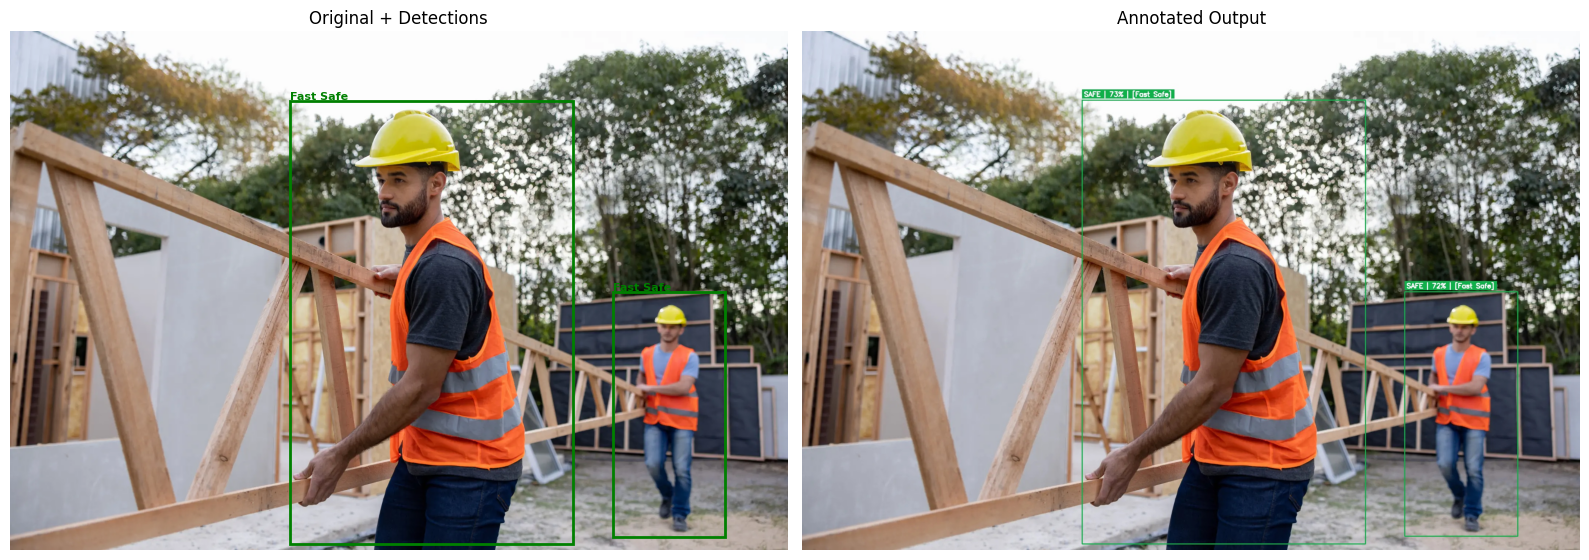

In [ ]:
import time, os, sys
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

sys.path.insert(0, '/content/backend')
os.chdir('/content/backend')

from services.hybrid_detector import get_hybrid_detector
detector = get_hybrid_detector()

# Run detection
print('Running hybrid detection (YOLO + SAM 3)...')
t0 = time.time()
result = detector.detect(
    test_image,
    save_annotated=True,
    output_path='/content/backend/uploads/test_annotated.jpg'
)
total_ms = (time.time() - t0) * 1000

# Results
print(f'\nTotal: {total_ms:.0f}ms')
print(f'Persons: {result["stats"]["total_persons"]}')
print(f'Violations: {result["stats"]["total_violations"]}')
print(f'Compliance: {result["stats"]["compliance_rate"]:.1f}%')
print(f'SAM activations: {result["stats"]["sam_activations"]}')
print(f'SAM bypass rate: {result["stats"]["bypass_rate"]:.1f}%')

# Path distribution
print(f'\nPath distribution:')
for path, count in result['stats']['path_distribution'].items():
    print(f'  {path}: {count}')

# Per-person detail
for i, p in enumerate(result['persons']):
    v = 'VIOLATION' if p['is_violation'] else 'SAFE'
    print(f'  Person {i+1}: {v} Helmet:{"Y" if p["has_helmet"] else "N"} Vest:{"Y" if p["has_vest"] else "N"} Path:{p["decision_path"]} SAM:{p["sam_activated"]}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
img_rgb = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
axes[0].imshow(img_rgb)
axes[0].set_title('Original + Detections')
for p in result['persons']:
    x1, y1, x2, y2 = p['bbox']
    c = 'red' if p['is_violation'] else 'green'
    axes[0].add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, lw=2, ec=c, fc='none'))
    axes[0].text(x1, y1-5, p['decision_path'], color=c, fontsize=8, fontweight='bold')
axes[0].axis('off')

ann_path = '/content/backend/uploads/test_annotated.jpg'
if os.path.exists(ann_path):
    axes[1].imshow(cv2.cvtColor(cv2.imread(ann_path), cv2.COLOR_BGR2RGB))
    axes[1].set_title('Annotated Output')
else:
    axes[1].text(0.5, 0.5, 'No annotated image', ha='center')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('/content/detection_result.png', dpi=150)
plt.show()

## 7. FPS Benchmark (YOLO)

In [ ]:
import time, numpy as np, matplotlib.pyplot as plt
from services.yolo_detector import get_yolo_detector
yolo = get_yolo_detector()

N = 20
latencies = []
for i in range(N):
    t0 = time.time()
    yolo.detect(test_image)
    latencies.append((time.time() - t0) * 1000)
    if (i+1) % 5 == 0: print(f'  {i+1}/{N}: {latencies[-1]:.1f}ms')

warm = latencies[3:]  # skip warmup
avg = np.mean(warm)
fps = 1000 / avg

print(f'\n{"="*40}')
print(f'YOLO BENCHMARK (Thesis)')
print(f'{"="*40}')
print(f'  Avg latency: {avg:.1f}ms')
print(f'  Min/Max: {np.min(warm):.1f} / {np.max(warm):.1f}ms')
print(f'  FPS: {fps:.1f}')
print(f'  Image size: 1280')
print(f'  GPU: {torch.cuda.get_device_name(0)}')

plt.figure(figsize=(10, 4))
plt.plot(warm, 'o-', color='#2196F3')
plt.axhline(avg, color='red', ls='--', label=f'Avg: {avg:.1f}ms ({fps:.1f} FPS)')
plt.xlabel('Run'); plt.ylabel('ms'); plt.title('YOLO Inference Latency')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('/content/benchmark_yolo.png', dpi=150)
plt.show()

## 8. SAM 3 Verification Stats

In [ ]:
from services.sam_verifier import get_sam_verifier

sam = get_sam_verifier()
stats = sam.get_stats()

print('SAM 3 VERIFICATION STATS')
print('=' * 40)
for k, v in stats.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.2f}')
    else:
        print(f'  {k}: {v}')

SAM 3 VERIFICATION STATS
  total_verifications: 3
  helmets_found: 0
  vests_found: 1
  total_time_ms: 3115.40
  errors: 0
  avg_time_ms: 1038.47
  mock_mode: False


## 9. Start API Server + ngrok

Get a free token at https://dashboard.ngrok.com/signup

In [ ]:
NGROK_TOKEN = 'YOUR_NGROK_TOKEN_HERE'  # paste your token

import subprocess, threading, time, requests, os
from pyngrok import ngrok, conf

conf.get_default().auth_token = NGROK_TOKEN
ngrok.kill()

def run_server():
    env = os.environ.copy()
    env['PYTHONPATH'] = '/content/backend'
    proc = subprocess.Popen(
        ['python', '-m', 'uvicorn', 'main:app', '--host', '0.0.0.0', '--port', '8000'],
        cwd='/content/backend',
        env=env,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True
    )
    for line in proc.stdout:
        print(f'[uvicorn] {line.strip()}')

threading.Thread(target=run_server, daemon=True).start()

print('Waiting for server...')
for i in range(120):
    try:
        if requests.get('http://localhost:8000/health', timeout=2).status_code == 200:
            print(f'Server ready ({i+1}s)')
            break
    except: pass
    if i % 10 == 9: print(f'  {i+1}s...')
    time.sleep(1)
else:
    raise RuntimeError('Server failed to start')

tunnel = ngrok.connect(8000)
url = tunnel.public_url
print(f'\n{"="*50}')
print(f'PUBLIC URL: {url}')
print(f'  Docs: {url}/docs')
print(f'  Health: {url}/health')
print(f'{"="*50}')
print(f"\nFor vite.config.js:")
print(f"const BACKEND_URL = '{url}'")

## 10. Test API

In [ ]:
import requests, json, cv2

# Health check
r = requests.get('http://localhost:8000/health')
print(f'Health: {r.status_code}')
print(json.dumps(r.json(), indent=2))

# Detection test
_, enc = cv2.imencode('.jpg', test_image)
r = requests.post(
    'http://localhost:8000/api/detect',
    files={'file': ('test.jpg', enc.tobytes(), 'image/jpeg')},
    data={'save_annotated': 'true'}
)
print(f'\nDetection: {r.status_code}')
d = r.json()
print(f'Persons: {d["stats"]["total_persons"]}, Violations: {d["stats"]["total_violations"]}')

## 11. Download Results

In [ ]:
from google.colab import files as gfiles
for p in ['/content/detection_result.png', '/content/benchmark_yolo.png',
          '/content/backend/uploads/test_annotated.jpg']:
    if os.path.exists(p):
        gfiles.download(p)
        print(f'Downloaded: {os.path.basename(p)}')
print('\nUse these in your thesis!')

---
## Thesis Metrics Summary

| Metric | Value |
|--------|-------|
| YOLO latency (ms) | _fill from Cell 7_ |
| YOLO FPS | _fill from Cell 7_ |
| SAM latency (ms) | _fill from Cell 8_ |
| SAM bypass rate | _fill from Cell 6_ |
| Fast path rate | _fill from Cell 6_ |
| Compliance rate | _fill from Cell 6_ |
| False positives corrected by SAM | _fill from Cell 6_ |

##Cell 1: Setup

In [ ]:
# ── SETUP FOR PIPELINE TEST ──
import sys, os
sys.path.insert(0, '/content/backend')
os.chdir('/content/backend')

# Init database with new table
from database.connection import engine
from database.models import Base
Base.metadata.create_all(bind=engine)

from sqlalchemy import inspect
tables = inspect(engine).get_table_names()
print(f"DB tables: {tables}")
assert 'verified_violations' in tables, "verified_violations table missing!"
print("Setup OK")


2026-04-06 06:21:36,746 INFO sqlalchemy.engine.Engine BEGIN (implicit)


INFO:sqlalchemy.engine.Engine:BEGIN (implicit)


2026-04-06 06:21:36,749 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("violations")


INFO:sqlalchemy.engine.Engine:PRAGMA main.table_info("violations")


2026-04-06 06:21:36,751 INFO sqlalchemy.engine.Engine [raw sql] ()


...

2026-04-06 06:21:36,764 INFO sqlalchemy.engine.Engine [raw sql] ()


INFO:sqlalchemy.engine.Engine:[raw sql] ()


2026-04-06 06:21:36,766 INFO sqlalchemy.engine.Engine ROLLBACK


INFO:sqlalchemy.engine.Engine:ROLLBACK


DB tables: ['daily_reports', 'verified_violations', 'violations']
Setup OK


##Cell 2: Upload Video + Run Full Pipeline

In [ ]:
# ── FULL SENTRY-JUDGE PIPELINE TEST ──
import sys, os
sys.path.insert(0, '/content/backend')
os.chdir('/content/backend')

from google.colab import files

# Upload video
print('Upload a test video (MP4/AVI)...')
uploaded = files.upload()
video_name = list(uploaded.keys())[0]
video_path = f'/content/{video_name}'
with open(video_path, 'wb') as f:
    f.write(uploaded[video_name])

# Run the pipeline
from run_pipeline import run_pipeline

results = run_pipeline(
    video_path=video_path,
    output_path='/content/output_pipeline.mp4',
    cooldown_seconds=300,
    roi_save_dir='/content/temp_rois',
    camera_zone='CAM-001',
)


Upload a test video (MP4/AVI)...


Saving 12098511-hd_1920_1080_50fps.mp4 to 12098511-hd_1920_1080_50fps.mp4
2026-04-06 06:23:32,572 INFO sqlalchemy.engine.Engine BEGIN (implicit)


INFO:sqlalchemy.engine.Engine:BEGIN (implicit)


2026-04-06 06:23:32,574 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("violations")


INFO:sqlalchemy.engine.Engine:PRAGMA main.table_info("violations")


...

2026-04-06 06:23:54,494 INFO sqlalchemy.engine.Engine [generated in 0.00237s] ()


INFO:sqlalchemy.engine.Engine:[generated in 0.00237s] ()


2026-04-06 06:23:54,496 INFO sqlalchemy.engine.Engine ROLLBACK


INFO:sqlalchemy.engine.Engine:ROLLBACK



COMBINED PIPELINE RESULTS

  SENTRY (YOLO + ByteTrack):
    Frames processed: 736
    Avg latency: 18.8ms
    FPS: 53.1
    Unique persons: 0
    Violations queued: 0
    Cooldown skips: 0

  JUDGE (SAM 3):
    Total processed: 0
    Confirmed: 0
    Rejected: 0
    Avg time: 0.0ms
    Confirmation rate: 0.0%
    SAM mock mode: False

  DATABASE:
    Verified violations stored: 0

  PIPELINE:
    Total time: 21.7s



##Cell 3: Inspect Results + Download

In [ ]:
# ── INSPECT RESULTS ──
import os, glob
from database.connection import SessionLocal
from database.models import VerifiedViolation

# Query all verified violations
session = SessionLocal()
violations = session.query(VerifiedViolation).all()
print(f"\n{'='*50}")
print(f"VERIFIED VIOLATIONS IN DATABASE: {len(violations)}")
print(f"{'='*50}")

for v in violations:
    print(f"  Person {v.person_id} | {v.violation_type} | {v.timestamp.strftime('%H:%M:%S')} | "
          f"Judge conf: {v.judge_confidence:.2f} | Path: {v.decision_path}")
session.close()

# Show saved ROI images
rois = glob.glob('/content/temp_rois/*.jpg')
print(f"\nSaved ROI evidence images: {len(rois)}")
for r in rois[:5]:
    print(f"  {os.path.basename(r)}")

# Show ROI images visually
import matplotlib.pyplot as plt
import cv2

if rois:
    n = min(6, len(rois))
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]
    for ax, path in zip(axes, rois[:n]):
        img = cv2.imread(path)
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(os.path.basename(path)[:30], fontsize=8)
        ax.axis('off')
    plt.suptitle('ROI Evidence Images sent to Judge')
    plt.tight_layout()
    plt.show()

# Download outputs
from google.colab import files as gfiles
for p in ['/content/output_pipeline.mp4']:
    if os.path.exists(p):
        gfiles.download(p)
        print(f"Downloaded: {os.path.basename(p)}")

# Download reports if any
for pdf in glob.glob('/content/backend/reports/*'):
    gfiles.download(pdf)
    print(f"Downloaded report: {os.path.basename(pdf)}")


2026-04-06 06:25:18,368 INFO sqlalchemy.engine.Engine BEGIN (implicit)


INFO:sqlalchemy.engine.Engine:BEGIN (implicit)


2026-04-06 06:25:18,372 INFO sqlalchemy.engine.Engine SELECT verified_violations.id AS verified_violations_id, verified_violations.timestamp AS verified_violations_timestamp, verified_violations.person_id AS verified_violations_person_id, verified_violations.camera_zone AS verified_violations_camera_zone, verified_violations.violation_type AS verified_violations_violation_type, verified_violations.image_path AS verified_violations_image_path, verified_violations.judge_confirmed AS verified_violations_judge_confirmed, verified_violations.judge_confidence AS verified_violations_judge_confidence, verified_violations.judge_processing_time_ms AS verified_violations_judge_processing_time_ms, verified_violations.sentry_confidence AS verified_violations_sentry_confidence, verified_violations.decision_path AS verified_violations_decision_path, verified_violations.person_bbox AS verified_violations_person_bbox, verified_violations.report_sent AS verified_violations_report_sent 
FROM verified_vio

INFO:sqlalchemy.engine.Engine:SELECT verified_violations.id AS verified_violations_id, verified_violations.timestamp AS verified_violations_timestamp, verified_violations.person_id AS verified_violations_person_id, verified_violations.camera_zone AS verified_violations_camera_zone, verified_violations.violation_type AS verified_violations_violation_type, verified_violations.image_path AS verified_violations_image_path, verified_violations.judge_confirmed AS verified_violations_judge_confirmed, verified_violations.judge_confidence AS verified_violations_judge_confidence, verified_violations.judge_processing_time_ms AS verified_violations_judge_processing_time_ms, verified_violations.sentry_confidence AS verified_violations_sentry_confidence, verified_violations.decision_path AS verified_violations_decision_path, verified_violations.person_bbox AS verified_violations_person_bbox, verified_violations.report_sent AS verified_violations_report_sent 
FROM verified_violations


2026-04-06 06:25:18,375 INFO sqlalchemy.engine.Engine [generated in 0.00240s] ()


...

INFO:sqlalchemy.engine.Engine:ROLLBACK



Saved ROI evidence images: 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: output_pipeline.mp4


In [ ]:
# ── TEST JUDGE WITH PERSON VERIFICATION ──────────────────────
import sys, os, glob, cv2, time
import matplotlib.pyplot as plt
sys.path.insert(0, '/content/backend')
os.chdir('/content/backend')

from services.judge import Judge
import queue
import importlib
import services.judge
importlib.reload(services.judge)
from services.judge import Judge
import numpy as np
# Create a dummy queue (we won't use it, just needed for init)
dummy_q = queue.Queue()
judge = Judge(queue=dummy_q, db_session_factory=None, roi_cleanup=False)

print(f"SAM mock mode: {judge.sam.is_mock()}")

# Get all saved ROI images
rois = sorted(glob.glob('/content/temp_rois/*.jpg'))
print(f"Found {len(rois)} ROI images\n")

results = []
for roi_path in rois:
    fname = os.path.basename(roi_path)
    parts = fname.replace('roi_p', '').split('_')
    person_id = parts[0]

    if 'no_helmet' in fname:
        violation_type = 'no_helmet'
    elif 'no_vest' in fname:
        violation_type = 'no_vest'
    else:
        violation_type = 'both_missing'

    roi = cv2.imread(roi_path)
    if roi is None:
        continue

    # Step 0: Person check
    t0 = time.time()
    is_person = judge._is_person(roi)
    person_ms = (time.time() - t0) * 1000

    if not is_person:
        print(f"  Person {person_id} | {violation_type} | NOT A PERSON -> REJECTED ({person_ms:.0f}ms)")
        results.append({
            'person_id': person_id, 'violation_type': violation_type,
            'is_person': False, 'confirmed': False, 'verdict': 'NOT A PERSON',
            'path': roi_path, 'ms': person_ms,
        })
        continue

    # Step 1: PPE check (only if person confirmed)
    t1 = time.time()
    confirmed, confidence = judge._verify_with_sam(roi, violation_type, [])
    total_ms = (time.time() - t0) * 1000

    verdict = "CONFIRMED (real violation)" if confirmed else "REJECTED (PPE found)"
    print(f"  Person {person_id} | {violation_type} | IS person | {verdict} | conf={confidence:.3f} ({total_ms:.0f}ms)")

    results.append({
        'person_id': person_id, 'violation_type': violation_type,
        'is_person': True, 'confirmed': confirmed, 'verdict': verdict,
        'path': roi_path, 'ms': total_ms,
    })

# Visualize
n = min(8, len(results))
if n > 0:
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    if n == 1: axes = np.array([[axes]])
    axes = np.array(axes).reshape(rows, cols) if n > 1 else axes

    import numpy as np
    for i, r in enumerate(results[:n]):
        row, col = i // cols, i % cols
        img = cv2.imread(r['path'])
        axes[row][col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        if not r['is_person']:
            color, border = 'blue', 'blue'
            title = f"P{r['person_id']}\nNOT A PERSON\nREJECTED"
        elif r['confirmed']:
            color, border = 'red', 'red'
            title = f"P{r['person_id']} - {r['violation_type']}\nCONFIRMED VIOLATION"
        else:
            color, border = 'green', 'green'
            title = f"P{r['person_id']} - {r['violation_type']}\nREJECTED (PPE found)"

        axes[row][col].set_title(title, fontsize=9, color=color, fontweight='bold')
        axes[row][col].axis('off')

    for i in range(n, rows * cols):
        axes[i // cols][i % cols].axis('off')

    plt.suptitle('JUDGE 2-STEP VERIFICATION', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/judge_2step_verdicts.png', dpi=150)
    plt.show()

# Summary
not_person = sum(1 for r in results if not r['is_person'])
confirmed = sum(1 for r in results if r['is_person'] and r['confirmed'])
rejected = sum(1 for r in results if r['is_person'] and not r['confirmed'])

print(f"\n{'='*50}")
print(f"JUDGE 2-STEP SUMMARY")
print(f"{'='*50}")
print(f"  Total ROIs: {len(results)}")
print(f"  Step 0 - NOT a person: {not_person} (buildings/objects filtered!)")
print(f"  Step 1 - CONFIRMED violations: {confirmed}")
print(f"  Step 1 - REJECTED (PPE found): {rejected}")


SAM mock mode: False
Found 0 ROI images


JUDGE 2-STEP SUMMARY
  Total ROIs: 0
  Step 0 - NOT a person: 0 (buildings/objects filtered!)
  Step 1 - CONFIRMED violations: 0
  Step 1 - REJECTED (PPE found): 0


## Raw tests

In [ ]:
from ultralytics import YOLO

# Load your specific model (update the path if needed)
model = YOLO("/content/drive/MyDrive/ppe_models/best.pt") # Or your Kaggle path

# Print the dictionary of classes
print("Classes baked into this model:")
print(model.names)

In [ ]:
import os
import glob
from ultralytics import YOLO

# 1. Load your custom model (update this path to your actual best.pt location)
model = YOLO("/content/drive/MyDrive/ppe_models/best.pt")

# 2. Define your uploaded video
# (Make sure you have uploaded a test video to your Colab workspace!)
video_path = "/content/12098511-hd_1920_1080_50fps.mp4"

print(f"Starting frame-by-frame processing for: {video_path}...")

# 3. Run the prediction
results = model.predict(
    source=video_path,
    conf=0.25,       # 25% confidence threshold
    imgsz=640,       # Forcing your training resolution!
    save=True,       # Save the output video with bounding boxes
    stream=True      # Memory-safe processing for videos
)

# 4. Execute the stream
# When using stream=True, you MUST loop through the results to trigger the processing
for frame_idx, frame_result in enumerate(results):
    if frame_idx % 30 == 0:  # Print an update every 30 frames
        print(f"Processed frame {frame_idx}...")

print("\n✅ Video processing complete!")

# ============================================================
# 5. AUTO-DOWNLOAD THE RESULT (If using Google Colab)
# ============================================================
try:
    from google.colab import files

    # YOLO saves outputs in runs/detect/predict... let's find the newest video file
    output_videos = glob.glob('runs/detect/predict*/*.avi') + glob.glob('runs/detect/predict*/*.mp4')

    if output_videos:
        # Find the most recently created video file
        latest_video = max(output_videos, key=os.path.getctime)
        print(f"Downloading annotated video: {latest_video}")
        files.download(latest_video)
    else:
        print("Could not find the saved output video.")
except ImportError:
    # If you run this locally instead of Colab, it will just skip the download step
    print("Check your 'runs/detect/' folder for the saved video!")

Starting frame-by-frame processing for: /content/12098511-hd_1920_1080_50fps.mp4...

video 1/1 (frame 1/736) /content/12098511-hd_1920_1080_50fps.mp4: 384x640 9 helmets, 4 vests, 25.3ms
Processed frame 0...
video 1/1 (frame 2/736) /content/12098511-hd_1920_1080_50fps.mp4: 384x640 7 helmets, 4 vests, 24.2ms
video 1/1 (frame 3/736) /content/12098511-hd_1920_1080_50fps.mp4: 384x640 8 helmets, 4 vests, 24.3ms
video 1/1 (frame 4/736) /content/12098511-hd_1920_1080_50fps.mp4: 384x640 8 helmets, 4 vests, 24.6ms
video 1/1 (frame 5/736) /content/12098511-hd_1920_1080_50fps.mp4: 384x640 7 helmets, 4 vests, 24.2ms
video 1/1 (frame 6/736) /content/12098511-hd_1920_1080_50fps.mp4: 384x640 7 helmets, 4 vests, 24.1ms
video 1/1 (frame 7/736) /content/12098511-hd_1920_1080_50fps.mp4: 384x640 7 helmets, 4 vests, 24.1ms
video 1/1 (frame 8/736) /content/12098511-hd_1920_1080_50fps.mp4: 384x640 8 helmets, 4 vests, 21.2ms
video 1/1 (frame 9/736) /content/12098511-hd_1920_1080_50fps.mp4: 384x640 8 helmets, 4

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Moduler Testing

In [ ]:
# ## 0. Environment Setup & Imports
# Run this cell to ensure your paths are set properly.

import os
import sys
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

# Ensure we are inside the 'backend' folder
if '/content/backend' not in sys.path:
    sys.path.insert(0, '/content/backend')
if os.path.exists('/content/backend'):
    os.chdir('/content/backend')
else:
    print("Warning: Ensure backend folder is set as your working directory.")

try:
    from services.yolo_detector import get_yolo_detector
    from services.sam_verifier import get_sam_verifier
    from services.hybrid_detector import get_hybrid_detector, DecisionPath
    from utils.bbox_utils import extract_head_roi, extract_torso_roi
    from config.settings import settings
except ImportError as e:
    print(f"Error importing internal modules: {e}")

# Helper to draw ROIs in matplotlib
def draw_roi(ax, bbox, color, label):
    x1, y1, x2, y2 = bbox
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor=color, facecolor='none', linestyle='--')
    ax.add_patch(rect)
    ax.text(x1, y1 - 5, label, color=color, fontsize=10, fontweight='bold', backgroundcolor='black')

In [ ]:

#1. Load Models Separately
# This step loads YOLO (Sentry) and SAM (Judge) independently.
print("Loading YOLO (Sentry)...")
yolo = get_yolo_detector()
yolo.load_model()
print(f"YOLO loaded - device: {yolo.device}")

print("\nLoading SAM 3 (Judge)...")
sam = get_sam_verifier()
sam.load_model()
print(f"SAM 3 loaded - mock mode: {sam.is_mock()}")

Loading YOLO (Sentry)...
YOLO loaded - device: cuda

Loading SAM 3 (Judge)...
SAM 3 loaded - mock mode: False


Upload a test image (JPG/PNG)...


Saving Worker-working-without-safety-boots-hand-gloves-head-protection_Q320 (1).jpg to Worker-working-without-safety-boots-hand-gloves-head-protection_Q320 (1) (2).jpg
Loaded: Worker-working-without-safety-boots-hand-gloves-head-protection_Q320 (1) (2).jpg (320x320px)
 STEP 1: YOLO INFERENCE
YOLO Processing time: 46.7ms
Detected 0 persons.


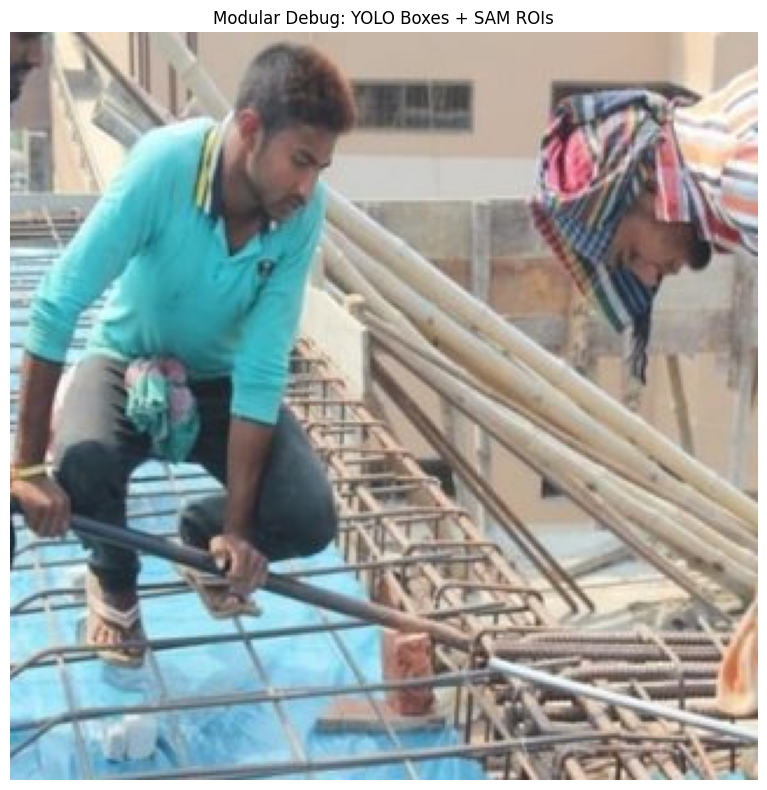

In [ ]:
# 2. TEST CASE: Single Image Modular Debugging
# Upload an image and see exactly what happens inside the pipeline.

from google.colab import files
print("Upload a test image (JPG/PNG)...")
try:
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    test_image = cv2.imdecode(np.frombuffer(uploaded[fname], np.uint8), cv2.IMREAD_COLOR)
    print(f"Loaded: {fname} ({test_image.shape[1]}x{test_image.shape[0]}px)")
except Exception as e:
    print("Skipping image upload test.")
    test_image = None

# RUN MODULAR PIPELINE ON IMAGE
if test_image is not None:
    print("========================================")
    print(" STEP 1: YOLO INFERENCE")
    print("========================================")
    yolo_start = time.time()

    # Temporarily lower confidence to catch borderline detections (like your other script)
    old_conf = yolo.confidence_threshold
    yolo.confidence_threshold = 0.25
    yolo_results = yolo.detect(test_image)
    yolo.confidence_threshold = old_conf

    print(f"YOLO Processing time: {(time.time() - yolo_start) * 1000:.1f}ms")

    persons = yolo_results["persons"]
    print(f"Detected {len(persons)} persons.")

    detector = get_hybrid_detector() # Use the hybrid detector to simulate path logic

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    img_rgb = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title("Modular Debug: YOLO Boxes + SAM ROIs")

    # Iterate through persons exactly like Hybrid Detector does
    for i, person in enumerate(persons):
        bbox = person["bbox"]
        conf = person["confidence"]
        helmet_det = person.get("helmet_detected", False)
        vest_det = person.get("vest_detected", False)

        print(f"\n--- Person {i+1} ---")
        print(f"YOLO BBox: {bbox}")
        print(f"YOLO Confidence: {conf:.2f}")
        print(f"YOLO says -> Helmet: {helmet_det}, Vest: {vest_det}")

        # Calculate expected Decision Path
        if helmet_det and vest_det:
            expected_path = "Fast Safe"
        elif person.get("no_helmet_detected", False) or person.get("no_vest_detected", False):
            expected_path = "Fast Violation"
        elif vest_det and not helmet_det:
            expected_path = "Rescue Head"
        elif helmet_det and not vest_det:
            expected_path = "Rescue Body"
        else:
            expected_path = "Critical"

        print(f"Decided Path: {expected_path}")

        # Plot Person BBox (Blue)
        draw_roi(ax, bbox, 'blue', f"Person {i+1} ({expected_path})")

        # Simulate SAM ROI extraction based on path
        if expected_path in ["Rescue Head", "Critical", "Fast Violation"]:
            # Evaluate Head ROI
            head_roi = extract_head_roi(bbox)
            print(f"  -> Extracted Head ROI: {head_roi}")
            draw_roi(ax, head_roi, 'yellow', 'Head ROI')

            # Manual SAM invocation
            sam_res = sam._verify_roi(test_image, head_roi, ["helmet", "hard hat", "safety helmet"], "helmet")
            print(f"  -> SAM Helmet says: {sam_res['helmet_found']} (Conf: {sam_res['confidence']:.3f})")

        if expected_path in ["Rescue Body", "Critical", "Fast Violation"]:
            # Evaluate Torso ROI
            torso_roi = extract_torso_roi(bbox)
            print(f"  -> Extracted Torso ROI: {torso_roi}")
            draw_roi(ax, torso_roi, 'orange', 'Torso ROI')

            # Manual SAM invocation
            sam_res = sam._verify_roi(test_image, torso_roi, ["safety vest", "high visibility vest", "reflective vest"], "vest")
            print(f"  -> SAM Vest says: {sam_res['vest_found']} (Conf: {sam_res['confidence']:.3f})")

    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# 3. TEST CASE: Video Modular Debugging with ROI Tracking
# Uses `cv2.VideoCapture` and explicitly tracks paths and ROIs across frames.

print("Upload a test video (MP4/AVI)...")
try:
    video_upload = files.upload()
    video_name = list(video_upload.keys())[0]
    video_path = f'/content/{video_name}'
    with open(video_path, 'wb') as f:
        f.write(video_upload[video_name])
except Exception as e:
    print("Skipping video upload test.")
    video_path = None

# %%
if video_path and os.path.exists(video_path):
    cap = cv2.VideoCapture(video_path)
    fps_in = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    out_path = '/content/modular_debug_output.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(out_path, fourcc, fps_in, (w, h))

    print(f"Processing Video: {video_path}...")
    frame_count = 0
    MAX_FRAMES = 150 # Process first 150 frames to be fast

    detector = get_hybrid_detector()

    while cap.isOpened() and frame_count < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret: break

        # 1. YOLO with tracking (MUST use .track() to get IDs, not .predict())
        yolo_results = yolo.model.track(
            frame,
            conf=0.25, # Explicitly lower to catch borderline detections
            imgsz=settings.yolo_imgsz,
            persist=True, # Required for tracking IDs across frames
            verbose=False
        )

        annotated_frame = frame.copy()

        if yolo_results[0].boxes is not None and yolo_results[0].boxes.id is not None:
            boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
            track_ids = yolo_results[0].boxes.id.cpu().numpy().astype(int)
            cls_ids = yolo_results[0].boxes.cls.cpu().numpy().astype(int)

            for box, tid, cls_id in zip(boxes, track_ids, cls_ids):
                if cls_id != 2: continue # Ensure it's a person

                # YOLO BBox
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(annotated_frame, (x1,y1), (x2,y2), (255, 0, 0), 2)
                cv2.putText(annotated_frame, f"ID: {tid}", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

                # We will draw the extracted Head & Torso ROIs so you can verify they are placed correctly!
                head_roi = extract_head_roi(box)
                hx1, hy1, hx2, hy2 = map(int, head_roi)
                cv2.rectangle(annotated_frame, (hx1, hy1), (hx2, hy2), (0, 255, 255), 2)
                cv2.putText(annotated_frame, "Head ROI", (hx1, hy1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)

                torso_roi = extract_torso_roi(box)
                tx1, ty1, tx2, ty2 = map(int, torso_roi)
                cv2.rectangle(annotated_frame, (tx1, ty1), (tx2, ty2), (0, 165, 255), 2)
                cv2.putText(annotated_frame, "Torso ROI", (tx1, ty1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 165, 255), 1)

        out.write(annotated_frame)
        frame_count += 1
        if frame_count % 30 == 0:
            print(f"Processed {frame_count} frames...")

    cap.release()
    out.release()
    print(f"Finished. Saved to {out_path}.")
    print("Download and review to see exact tracked ROIs.")

# You can now download `modular_debug_output.mp4` to visualize the tracking and ROI extraction box fidelity.


Upload a test video (MP4/AVI)...


Saving 12098511-hd_1920_1080_50fps.mp4 to 12098511-hd_1920_1080_50fps (2).mp4
Processing Video: /content/12098511-hd_1920_1080_50fps (2).mp4...
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 282ms
Prepared 1 package in 56ms
Installed 1 package in 4ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Processed 30 frames...
Processed 60 frames...
Processed 90 frames...
Processed 120 frames...
Processed 150 frames...
Finished. Saved to /content/modular_debug_output.mp4.
Download and review to see exact tracked ROIs.
